### **Remote Path**

In [1]:
import sys

sys.path.append('/home/dyuser-e/NI_project_dyuser-e_2026/dynap-se1')

### **Local Path**

In [ ]:
import sys
from pathlib import Path

dynapse_path = Path.home() / "NI_project" / "dynap-se1"
sys.path.append(str(dynapse_path))

### **Imports**

In [2]:

import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1

import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator

import params
from params import set_params

import time
from IPython.display import Image
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

### **Remote Connection**

In [ ]:
# get index for board (DONT USE TO CONNECT)

model, _ = ut.open_dynapse1(gui=False, select_device=True)

In [ ]:
model = ut.open_specific_device_in_sequence(3)

### **Local Connection**

In [3]:
model, _ = ut.open_dynapse1()

[0]:  Bus 1 Device 8 Dynapse1DevKit serial_number 00000020
Selected device: 00000020
Sender port: tcp://0.0.0.0:38077
Receiver port: tcp://0.0.0.0:51441
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2


### Initialize Dynap-SE

In [1642]:
api = model.get_dynapse1_api()          # get Dynapse1 api from the model
set_params(model)                       # set standard parameters


core_id     = 0
config1     = model.get_configuration() 
param_group = config1.chips[0].cores[0].parameter_group 

### **Set Neuron/Dendrite Parameters - param_mat**

In [1643]:
# set AMPA (fast excitatory) weight 
param_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value   = 90
param_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 5

# set NMDA (slow excitatory) weight
param_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value   = 120    #before 70
param_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 5

# set GABA B (slow inhibitory) weight
param_group.param_map['PS_WEIGHT_INH_S_N'].fine_value   = 60
param_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 5

# set GABA A (fast inhibitory) weight
param_group.param_map['PS_WEIGHT_INH_F_N'].fine_value =  80      #100
param_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 5

# set NMDA (slow exc) tau   
# remember the higher the tau param, the higher the leak, the faster the decay
param_group.param_map['NPDPIE_TAU_S_P'].fine_value   = 40
param_group.param_map['NPDPIE_TAU_S_P'].coarse_value = 4

# set AMPA (fast exc) tau 
param_group.param_map['NPDPIE_TAU_F_P'].fine_value   = 30
param_group.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

# set GABA A (fast inhibitory) tau                              #added this
#param_group.param_map['NPDPII_TAU_F_P'].fine_value = 40
#param_group.param_map['NPDPII_TAU_F_P'].coarse_value = 4

#GABA B (slow inhibitory) tau
param_group.param_map['NPDPII_TAU_S_P'].fine_value = 100
param_group.param_map['NPDPII_TAU_S_P'].coarse_value = 4

# Neuron membrane voltage gain
#param_group.param_map['IF_THR_N'].fine_value = 80
#param_group.param_map['IF_THR_N'].coarse_value = 5

# Refactory period (Standard 4, 128?)
param_group.param_map['IF_RFR_N'].fine_value = 40
param_group.param_map['IF_RFR_N'].coarse_value = 4

# Bias Current (Standard 0, 0)
param_group.param_map["IF_DC_P"].coarse_value = 1
param_group.param_map["IF_DC_P"].fine_value = 70


In [1644]:
# print AMPA weight values

print("\n--- AMPA (fast excitatory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))


# print NMDA (slow excitatory) weight

print("\n--- NMDA (slow excitatory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value))


# print GABA B (slow inhibitory) weight

print("\n--- GABA B (slow inhibitory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].fine_value))


# print GABA A (fast inhibitory) weight

print("\n--- GABA A (fast inhibitory) weight ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].fine_value))


# print NMDA (slow exc) tau

print("\n--- NMDA tau (slow excitatory) ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_S_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].fine_value))


# print AMPA (fast exc) tau

print("\n--- AMPA tau (fast excitatory) ---")
print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_F_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].fine_value))


# refactory period

print("\n--- Refractory period ---")
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['IF_RFR_N'].coarse_value))
print("Fine: "   + str(config1.chips[0].cores[0].parameter_group.param_map['IF_RFR_N'].fine_value))



--- AMPA (fast excitatory) weight ---
Linear: 14117648.0
Coarse: 5
Fine: 90

--- NMDA (slow excitatory) weight ---
Linear: 18823530.0
Coarse: 5
Fine: 120

--- GABA B (slow inhibitory) weight ---
Linear: 9411765.0
Coarse: 5
Fine: 60

--- GABA A (fast inhibitory) weight ---
Linear: 12549020.0
Coarse: 5
Fine: 80

--- NMDA tau (slow excitatory) ---
Linear: 784314.0
Coarse: 4
Fine: 40

--- AMPA tau (fast excitatory) ---
Linear: 588824.0
Coarse: 4
Fine: 30

--- Refractory period ---
Coarse: 4
Fine: 40


### **Set Network Parameters**

#### Set Connection Probabilites

In [1645]:

model.update_parameter_group(param_group, 0, 0)

NE = 16          # neurons per excitatory state population
NI = 12           # inhibitory population size
NS = 3           # number of excitatory state populations
NG = 3           # Nr of spike generators

exclude_n_ids = [(0,0,7),(0,0,8),(0,0,9),(0,0,27),(0,0,28)]
seed = 50

p_S_S_AMPA      = np.full(NS, 0.8)  # Base Prob
p_S_S_NMDA      = np.full(NS, 0.1)  # NMDA/AMPA
p_S_I           = np.full(NS, 0.6)  # excitation from each state population to inhibitory pool
p_I_S_GABA_A    = np.full(NS, 0.7)  # Base Prob 0.4
p_I_S_GABA_B    = np.full(NS, 0.9)  # GABA_B/GABA_A 0.9
p_I_I           = 0.1  # optional inhibitory recurrence
p_G_S           = 0.4  # spike generator to state population
p_S_S_self      = np.full(NS, 0.5)
p_I_I_self      = 0.0

identical_connections    = False # Create exact same connections for s populations
pop_specific_connections = False # Apply population specific connection probabilities

#### Adjust Connection Probabilities Population Specific

In [1646]:
if pop_specific_connections is True:
    s = 0

    p_S_S_AMPA[s]   = p_S_S_AMPA[s] - 0.00
    p_S_S_NMDA[s]   = p_S_S_NMDA[s] - 0.0
    p_S_S_self[s]   = p_S_S_self[s] - 0.0

    p_I_S_GABA_A[s] = p_I_S_GABA_A[s]

    s = 1

    p_S_S_AMPA[s]   = p_S_S_AMPA[s] - 0.00
    p_S_S_NMDA[s]   = p_S_S_NMDA[s] - 0.0
    p_S_S_self[s]   = p_S_S_self[s] - 0.00

    p_I_S_GABA_A[s] = p_I_S_GABA_A[s] 

    s = 2

    p_I_S_GABA_A[s] = p_I_S_GABA_A[s] + 0.00


#### Define Spike Input Rates

In [1647]:
lr    = 10      # low rate (Hz)
hr    = 100    # high rate (Hz)

stim_rates = np.linspace(lr,lr,20)
stim_rates_hz = [[rate, rate, rate] for rate in stim_rates ]

stim_rates_hz[3][0] = hr
stim_rates_hz[4][0] = hr

stim_rates_hz[7][1] = hr
stim_rates_hz[8][1] = hr


stim_rates_hz[12][2] = hr
stim_rates_hz[13][2] = hr


dt_stim       = 1
t_steps_stim  = dt_stim*np.ones_like(stim_rates)
t_post_stim   = 2.0
t_tot         = sum(t_steps_stim) + t_post_stim

print(t_tot)

22.0


In [1648]:

rng = np.random.default_rng(seed)

net_gen = NetworkGenerator()
net_gen.clear_network()


### **Build Network**

#### Create Populations

In [1649]:
def make_population(
    size,
    next_true_nid,
    next_disp_idx,
    chip,             
    core,             
    exclude_n_ids,    
    true_to_disp_idx,
    is_spikegen = False,
):
    exclude_n_ids = set(exclude_n_ids or [])

    pop_ids = []
    nid     = next_true_nid

    while len(pop_ids) < size:

        true_id = (chip, core, nid)

        if true_id not in exclude_n_ids:
            pop_ids.append(true_id)

            true_to_disp_idx[true_id] = next_disp_idx
            next_disp_idx += 1

        nid += 1

    pop = [Neuron(chip_, core_, nid_, is_spikegen) for chip_, core_, nid_ in pop_ids]

    next_true_nid = nid

    return pop, pop_ids, next_true_nid, true_to_disp_idx, next_disp_idx

In [1650]:

S_pops = []
E_ids  = []

next_true_nid       = 1                 # index as appears on the dynapse
next_disp_idx       = 0                 # index as displayed on plots
true_to_disp_idx    = {}                # dictionary mapping true dynapse index to displayed index

for s in range(NS):

    S_pop, S_ids, next_true_nid, true_to_disp_idx, next_disp_idx = make_population(
        size               = NE,
        next_true_nid      = next_true_nid,
        next_disp_idx      = next_disp_idx,
        chip               = 0,
        core               = core_id,
        exclude_n_ids      = exclude_n_ids,
        true_to_disp_idx   = true_to_disp_idx,
    )

    S_pops.append(S_pop)
    E_ids.extend(S_ids)


I_pop, I_ids, next_true_nid, true_to_disp_idx, next_disp_idx = make_population(
        size               = NI,
        next_true_nid      = next_true_nid,
        next_disp_idx      = next_disp_idx,
        chip               = 0,
        core               = core_id,
        exclude_n_ids      = exclude_n_ids,
        true_to_disp_idx   = true_to_disp_idx,
    )


spikegens, spikegen_ids, next_true_nid, true_to_disp_idx, next_disp_idx = make_population(
        size               = NG,
        next_true_nid      = 1,
        next_disp_idx      = next_disp_idx,
        chip               = 0,
        core               = 1,
        exclude_n_ids      = exclude_n_ids,
        true_to_disp_idx   = true_to_disp_idx,
        is_spikegen        = True
    )


#### Connection Matrix

In [1651]:
# ------------------------------------------------------------
# CONSTRUCT CONNECTION MATRIX
# ------------------------------------------------------------

N_hw  = NE * NS + NI   # all real neurons
N_tot = N_hw + NG      # real neurons + spike generators

C = np.zeros((N_tot, N_tot))


def get_idx(n):
    true_id = (0, n.core_id, n.neuron_id)

    return true_to_disp_idx[true_id]


def add_conn(src, tgt, syn_type):
    net_gen.add_connection(src, tgt, syn_type)

    src_idx = get_idx(src)
    tgt_idx = get_idx(tgt)

    if syn_type == dyn1.Dynapse1SynType.AMPA:
        C[src_idx, tgt_idx] = 1

    elif syn_type == dyn1.Dynapse1SynType.GABA_A:
        C[src_idx, tgt_idx] = -1

    elif syn_type == dyn1.Dynapse1SynType.NMDA:
        C[src_idx, tgt_idx] = 2

    elif syn_type == dyn1.Dynapse1SynType.GABA_B:
        C[src_idx, tgt_idx] = -2

#### Create Connections

In [1652]:

# ------------------------------------------------------------
# CONNECT SPIKEGENS -> STATE POPULATIONS - DETERMINISTIC
# ------------------------------------------------------------
for j in range(NS):
    k = 0
    for neuron in S_pops[j]:
        if k < NE * p_G_S:
            add_conn(spikegens[j], neuron, dyn1.Dynapse1SynType.AMPA)
            k += 1

# ------------------------------------------------------------
# CONNECT S_i -> S_i (Probabilistic E recurrence)
# ------------------------------------------------------------
for s in range(NS):
    for i in range(NE):
        for j in range(NE):
            if i == j and rng.random() < p_S_S_self[s]:
                if rng.random() < p_S_S_NMDA[s]:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.NMDA)
                else:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.AMPA
                    )
                    
            if i != j and rng.random() < p_S_S_AMPA[s]:
                if rng.random() < p_S_S_NMDA[s]:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.NMDA)
                else:
                    add_conn(
                    S_pops[s][i],
                    S_pops[s][j],
                    dyn1.Dynapse1SynType.AMPA
                    )

# ------------------------------------------------------------
# CONNECT S_i -> I (Probabilistic)
# ------------------------------------------------------------
for s in range(NS):
    for e_neuron in S_pops[s]:
        for i_neuron in I_pop:
            if rng.random() < p_S_I[s]:
                add_conn(
                    e_neuron,
                    i_neuron,
                    dyn1.Dynapse1SynType.AMPA
                )

# ------------------------------------------------------------
# CONNECT I -> S_i (Probabilistic)
# ------------------------------------------------------------
for i_neuron in I_pop:
    for s in range(NS):
        for e_neuron in S_pops[s]:
            if rng.random() < p_I_S_GABA_A[s]:
                if rng.random() < p_I_S_GABA_B[s]:
                    add_conn(
                        i_neuron,
                        e_neuron,
                        dyn1.Dynapse1SynType.GABA_B
                    )
                else:
                    add_conn(
                        i_neuron,
                        e_neuron,
                        dyn1.Dynapse1SynType.GABA_A
                    )

# ------------------------------------------------------------
# CNNECT I -> I (Probabilistic)
# ------------------------------------------------------------
if p_I_I > 0:
    for i in range(NI):
        for j in range(NI):
            if i == j and rng.random() < p_I_I_self:
                add_conn(
                    I_pop[i],
                    I_pop[j],
                    dyn1.Dynapse1SynType.GABA_A
                )
            if i != j and rng.random() < p_I_I:
                add_conn(
                    I_pop[i],
                    I_pop[j],
                    dyn1.Dynapse1SynType.GABA_A
                )



In [1653]:
if identical_connections is True:

   
    S_pops = []
    E_ids  = []

    next_true_idx = 1
    for s in range(NS):
        pop_ids = [(0, 0, nid) for nid in range(next_true_idx, next_true_idx + NE)]
        pop     = [Neuron(chip, core, nid) for chip, core, nid in pop_ids]

        S_pops.append(pop)
        E_ids.extend(pop_ids)

        next_true_idx += NE


    I_ids = [(0, 0, nid) for nid in range(next_true_idx, next_true_idx + NI)]
    I_pop = [Neuron(chip, core, nid) for chip, core, nid in I_ids]


    # ------------------------------------------------------------
    # CONNECT SPIKEGENS -> STATE POPULATIONS - DETERMINISTIC
    # ------------------------------------------------------------
    for j in range(NS):
        k = 0
        for neuron in S_pops[j]:
            if k < NE * p_G_S:
                add_conn(spikegens[j], neuron, dyn1.Dynapse1SynType.AMPA)
                k += 1

    # ------------------------------------------------------------
    # CONNECT S_i -> S_i (Probabilistic E recurrence)
    # ------------------------------------------------------------
    for i in range(NE):
        for j in range(NE):
            if i == j and rng.random() < p_S_S_self[0]:
                if rng.random() < p_S_S_NMDA[0]:
                    for s in range(NS):
                        add_conn(
                        S_pops[s][i],
                        S_pops[s][j],
                        dyn1.Dynapse1SynType.NMDA)
                else:
                    for s in range(NS):
                        add_conn(
                        S_pops[s][i],
                        S_pops[s][j],
                        dyn1.Dynapse1SynType.AMPA
                        )
                    
            if i != j and rng.random() < p_S_S_AMPA[0]:
                if rng.random() < p_S_S_NMDA[0]:
                    for s in range(NS):
                        add_conn(
                        S_pops[s][i],
                        S_pops[s][j],
                        dyn1.Dynapse1SynType.NMDA)
                else:
                    for s in range(NS):
                        add_conn(
                        S_pops[s][i],
                        S_pops[s][j],
                        dyn1.Dynapse1SynType.AMPA
                        )

    # ------------------------------------------------------------
    # CONNECT S_i -> I (Probabilistic)
    # ------------------------------------------------------------
    for e_idx in range(NE):
        for i_neuron in I_pop:
            if rng.random() < p_S_I[0]:
                for s in range(NS):
                    add_conn(
                        S_pops[s][e_idx],
                        i_neuron,
                        dyn1.Dynapse1SynType.AMPA
                    )

    # ------------------------------------------------------------
    # CONNECT I -> S_i (Probabilistic)
    # ------------------------------------------------------------
    for i_neuron in I_pop:
        if rng.random() < p_I_S_GABA_A[0]:
            if rng.random() < p_I_S_GABA_B[0]:
                for s in range(NS):
                    for e_neuron in S_pops[s]:
                        add_conn(
                            i_neuron,
                            e_neuron,
                            dyn1.Dynapse1SynType.GABA_B
                        )
            else:
                for s in range(NS):
                    for e_neuron in S_pops[s]:
                        add_conn(
                            i_neuron,
                            e_neuron,
                            dyn1.Dynapse1SynType.GABA_A
                        )

    # ------------------------------------------------------------
    # CNNECT I -> I (Probabilistic)
    # ------------------------------------------------------------
    if p_I_I > 0:
        for i in range(NI):
            for j in range(NI):
                if i == j and rng.random() < p_I_I_self:
                    add_conn(
                        I_pop[i],
                        I_pop[j],
                        dyn1.Dynapse1SynType.GABA_A
                    )
                if i != j and rng.random() < p_I_I:
                    add_conn(
                        I_pop[i],
                        I_pop[j],
                        dyn1.Dynapse1SynType.GABA_A
                    )



### **Plot Connection Matrix**

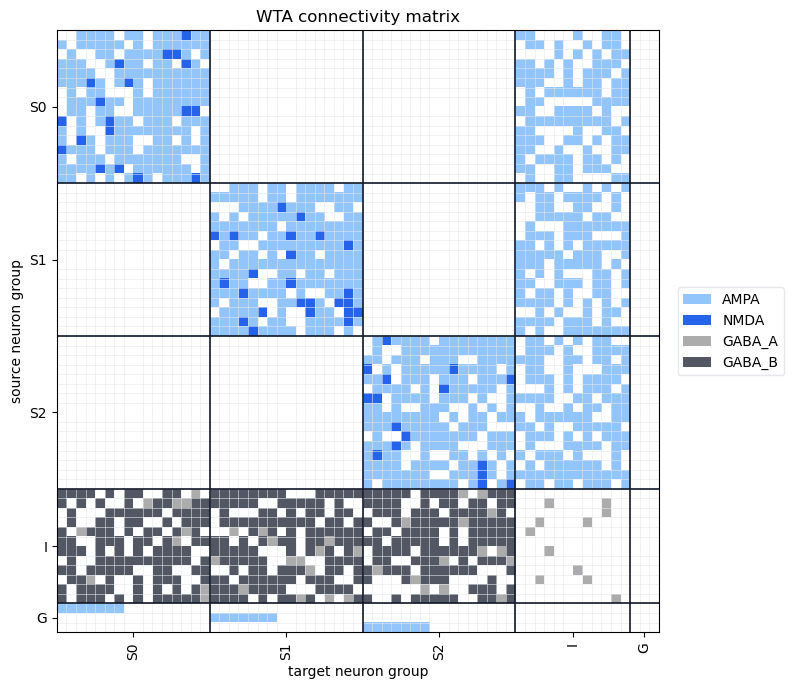

In [1654]:

plt.clf()
plt.close("all")

fig, ax = plt.subplots(figsize=(8, 8))


# ------------------------------------------------------------
# DISCRETE SYNAPSE COLORS
# ------------------------------------------------------------
syn_colors = {
    "GABA_B": "#525763",
    "GABA_A": "#acacac",
    "none":   "#ffffff",
    "AMPA":   "#93c5fd",
    "NMDA":   "#2563eb",
}

colors = [
    syn_colors["GABA_B"],
    syn_colors["GABA_A"],
    syn_colors["none"],
    syn_colors["AMPA"],
    syn_colors["NMDA"],
]

cmap = ListedColormap(colors)

bounds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
norm   = BoundaryNorm(bounds, cmap.N)


# ------------------------------------------------------------
# CONNECTIVITY MATRIX
# ------------------------------------------------------------
im = ax.imshow(
    C,
    cmap          = cmap,
    norm          = norm,
    interpolation = "none",
    aspect        = "equal"
)


# ------------------------------------------------------------
# GROUP DEFINITIONS
# Matrix ordering assumed:
# S0, S1, ..., S_NS-1, G, I
# ------------------------------------------------------------
NG = NS          # one input generator per state population

group_specs = []

for s in range(NS):
    group_specs.append((f"S{s}", NE))

group_specs.append(("I", NI))
group_specs.append(("G", NG))

group_sizes  = [size for _, size in group_specs]
group_labels = [name for name, _ in group_specs]

N_plot = sum(group_sizes)

if C.shape != (N_plot, N_plot):
    raise ValueError(
        f"C has shape {C.shape}, but group sizes imply "
        f"({N_plot}, {N_plot}). Check group ordering or sizes."
    )


# ------------------------------------------------------------
# CELL GRID
# ------------------------------------------------------------
ax.set_xticks(np.arange(N_plot + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(N_plot + 1) - 0.5, minor=True)

ax.grid(
    which     = "minor",
    color     = "#e5e7eb",
    linestyle = "-",
    linewidth = 0.4
)

ax.tick_params(which="minor", bottom=False, left=False)


# ------------------------------------------------------------
# GROUP BOUNDARIES
# ------------------------------------------------------------
boundaries = np.cumsum(group_sizes)

boundary_color = "#111827"

for b in boundaries[:-1]:
    ax.axhline(b - 0.5, color=boundary_color, linewidth=1.2)
    ax.axvline(b - 0.5, color=boundary_color, linewidth=1.2)


# ------------------------------------------------------------
# GROUP LABELS
# ------------------------------------------------------------
centers = boundaries - np.array(group_sizes) / 2 - 0.5

ax.set_xticks(centers)
ax.set_yticks(centers)

ax.set_xticklabels(group_labels, rotation=90)
ax.set_yticklabels(group_labels)

ax.set_xlabel("target neuron group")
ax.set_ylabel("source neuron group")
ax.set_title("WTA connectivity matrix")


# ------------------------------------------------------------
# LEGEND
# ------------------------------------------------------------
legend_elements = [
    Patch(facecolor=syn_colors["AMPA"],   edgecolor="none", label="AMPA"),
    Patch(facecolor=syn_colors["NMDA"],   edgecolor="none", label="NMDA"),
    Patch(facecolor=syn_colors["GABA_A"], edgecolor="none", label="GABA_A"),
    Patch(facecolor=syn_colors["GABA_B"], edgecolor="none", label="GABA_B"),
]

ax.legend(
    handles    = legend_elements,
    loc        = "center left",
    bbox_to_anchor = (1.02, 0.5),
    frameon    = True,
    framealpha = 1.0,
    edgecolor  = "#e5e7eb"
)

plt.tight_layout()
plt.show()

In [1655]:
# ------------------------------------------------------------
# APPLY CONFIGURATION
# ------------------------------------------------------------
new_config = net_gen.make_dynapse1_configuration()
model.apply_configuration(new_config)

set_params(model, param_group=param_group)

# ------------------------------------------------------------
# PREPARE POISSON INPUT
# ------------------------------------------------------------
global_poisson_gen_ids = ut.get_global_id_list(spikegen_ids)
poisson_gen            = model.get_poisson_gen()
poisson_gen.set_chip_id(0)

# set initial rates to zero
for gid in global_poisson_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, 0)

# ------------------------------------------------------------
# MONITOR NEURONS
# ------------------------------------------------------------
monitored_neurons = E_ids + I_ids
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)
graph.start()
# filter_node.set_neurons(monitored_neurons)

# clear buffer
sink_node.get_events()
api.reset_timestamp()

### **Create Input Spike-Train**

In [1656]:
# ------------------------------------------------------------
# CREATE POISSON SPIKE TIMES
# ------------------------------------------------------------
spike_times  = []
indices      = []
target_chips = []

t0 = 0.0

for i, duration in enumerate(t_steps_stim):

    for gen_id, rate in zip(global_poisson_gen_ids, stim_rates_hz[i]):

        n_spikes = np.random.poisson(rate * duration)
        
        times = t0 + np.sort(np.random.rand(n_spikes) * duration)
        
        spike_times.extend(times)
        indices.extend([gen_id] * n_spikes)
        target_chips.extend([0] * n_spikes)

    t0 += duration


# Then sort all spikes globally in time:
spike_times  = np.array(spike_times)
indices      = np.array(indices)
target_chips = np.array(target_chips)

sort_idx = np.argsort(spike_times)

spike_times  = spike_times[sort_idx]
indices      = indices[sort_idx]
target_chips = target_chips[sort_idx]


# Then load the stimulus:
fpga_spike_gen = model.get_fpga_spike_gen()

ut.set_fpga_spike_gen(
    fpga_spike_gen = fpga_spike_gen,
    spike_times    = spike_times,
    indices        = indices,
    target_chips   = target_chips,
    isi_base       = 900,
    repeat_mode    = False
)

New configuration applied to DYNAP-SE1!
VariableIsiMode already 1
RepeatMode already 0


In [1657]:
from tools.spikegen_tools import get_instantaneous_activity

# ------------------------------------------------------------
# INSTANTANEOUS POPULATION ACTIVITY
# ------------------------------------------------------------
activity_dt_s = 0.2
exp_tc_s      = 0.02


def population_activity(t_spikes, n_neurons):
    t_spikes = np.asarray(t_spikes, dtype=float)
    t_spikes = np.sort(t_spikes[(t_spikes >= 0) & (t_spikes < t_tot)])

    if len(t_spikes) == 0:
        activity_x    = np.arange(0, t_tot, activity_dt_s)
        activity_rate = np.zeros_like(activity_x)
        return activity_rate, activity_x

    activity_hz, activity_x = get_instantaneous_activity(
        t_spikes,
        activity_dt_s,
        exp_tc_s
    )

    activity_hz = np.asarray(activity_hz, dtype=float)
    activity_x  = np.asarray(activity_x, dtype=float)

    mask = activity_x < t_tot

    activity_rate = activity_hz[mask] / n_neurons
    activity_x    = activity_x[mask]

    return activity_rate, activity_x


### **Plot Stimulation Rates**

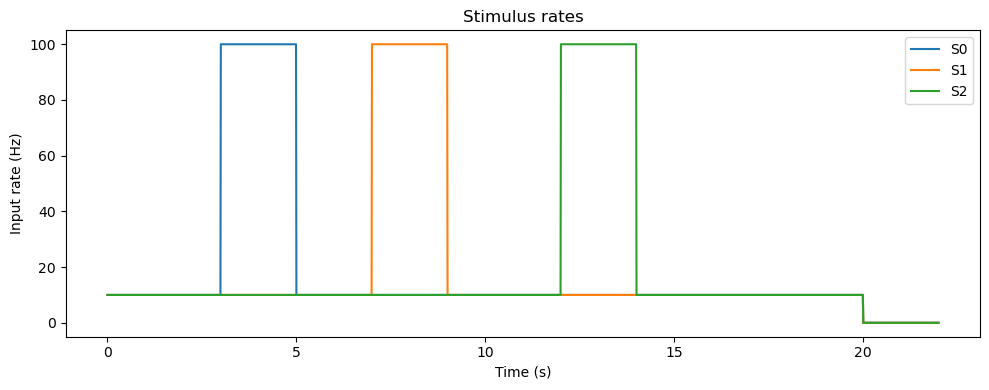

In [1658]:

fs = 100

stim_rates_hz = np.array(stim_rates_hz)
t             = np.arange(0, t_tot, 1/fs)

# allocate rate matrix
rates = np.zeros((NS, len(t)))

# fill piecewise constant segments
t_cursor = 0
for i, dt in enumerate(t_steps_stim):
    idx_start = int(t_cursor * fs)
    idx_end   = int((t_cursor + dt) * fs)

    for s in range(NS):
        rates[s, idx_start:idx_end] = stim_rates_hz[i, s]

    t_cursor += dt

plt.figure(figsize=(10,4))

for s in range(NS):
    plt.plot(t, rates[s], label=f"S{s}")

plt.xlabel("Time (s)")
plt.ylabel("Input rate (Hz)")
plt.title("Stimulus rates")
plt.legend()
plt.tight_layout()
plt.show()


### **Run Simulation**

In [1659]:
# Run Simulation
fpga_spike_gen.start()
time.sleep(t0)
fpga_spike_gen.stop()

# turn off stimulus

for gid in global_poisson_gen_ids:
    poisson_gen.write_poisson_rate_hz(gid, 0)

poisson_gen.stop()
time.sleep(t_tot)

graph.stop()
events = sink_node.get_events()

print(f"{len(events)} events recorded.")

PoissonGen already off!
7199 events recorded.


### **Post Simulation Processing**

In [1660]:
# ------------------------------------------------------------
# EXTRACT EVENTS
# ------------------------------------------------------------

spike_id_true = []
spike_id      = []     # display ids
spike_t       = []

N_hw = NS * NE + NI    # only real output neurons, not spike generators

for evt in events:

    true_id = (0, 0, int(evt.neuron_id))   # chip, core, true neuron id

    # Skip events from neurons that are not part of the defined populations
    if true_id not in true_to_disp_idx:
        continue

    disp_id = true_to_disp_idx[true_id]

    # Skip spike generators if they are also included in true_to_disp_idx
    if disp_id >= N_hw:
        continue

    spike_id_true.append(evt.neuron_id)
    spike_id.append(disp_id)
    spike_t.append(evt.timestamp * 1e-6)

spike_id_true = np.asarray(spike_id_true)
spike_id      = np.asarray(spike_id)
spike_t       = np.asarray(spike_t)


# ------------------------------------------------------------
# FILTER SPIKES BY POPULATION
# ------------------------------------------------------------

S_spike_t  = []
S_spike_id = []

for s in range(int(NS)):

    lower = s * NE
    upper = (s + 1) * NE

    mask = (spike_id >= lower) & (spike_id < upper)

    S_spike_t.append(spike_t[mask])
    S_spike_id.append(spike_id[mask])


lower_I = NS * NE
upper_I = NS * NE + NI

mask_I = (spike_id >= lower_I) & (spike_id < upper_I)

I_spike_t  = spike_t[mask_I]
I_spike_id = spike_id[mask_I]


# ------------------------------------------------------------
# BIN FILTERED SPIKES
# ------------------------------------------------------------

fs     = 1.2
n_bins = int(t_tot * fs)

binPOP = np.zeros((NS + 1, n_bins))

for s in range(int(NS + 1)):

    if s < NS:
        t_spikes = S_spike_t[s]
    else:
        t_spikes = I_spike_t

    t_spikes = t_spikes[t_spikes < t_tot]

    counts, _ = np.histogram(
        t_spikes,
        bins  = n_bins,
        range = (0, t_tot)
    )

    binPOP[s, :] = counts


# total excitatory activity, all S populations pooled
binPOP_E = np.sum(binPOP[:NS, :], axis=0)

# mean number of spikes per excitatory neuron over full simulation
binPOP_tot_mean = np.sum(binPOP[:NS, :]) / (NS * NE)


# ------------------------------------------------------------
# POPULATION FIRING ACTIVITY
# ------------------------------------------------------------

idx_end = int(t_tot * fs)
t_axis  = np.arange(idx_end) / fs

pop_sizes = np.r_[np.full(NS, NE), NI]

binPOP_rate = binPOP[:, :idx_end] * fs / pop_sizes[:, None]


# ------------------------------------------------------------
# FIRING ACTIVITY PER STIMULUS WINDOW
# ------------------------------------------------------------

stim_start = np.cumsum(np.r_[0, t_steps_stim[:-1]])
stim_end   = stim_start + t_steps_stim

out_rates = np.zeros((NS, len(stim_rates)))

for s in range(int(NS)):

    for i, (t0, t1) in enumerate(zip(stim_start, stim_end)):

        b0 = int(t0 * fs)
        b1 = int(t1 * fs)

        n_spikes = np.sum(binPOP[s, b0:b1])

        # mean firing rate per neuron in population S{s}
        out_rates[s, i] = n_spikes / ((t1 - t0) * NE)

In [1661]:
S_activity_rate = []
S_activity_x    = []

for s in range(int(NS)):
    rate, x = population_activity(S_spike_t[s], NE)

    S_activity_rate.append(rate)
    S_activity_x.append(x)


I_activity_rate, I_activity_x = population_activity(I_spike_t, NI)


# total excitatory activity, all S populations pooled
E_spike_t = np.concatenate(S_spike_t)

E_activity_rate, E_activity_x = population_activity(
    E_spike_t,
    int(NS) * NE
)

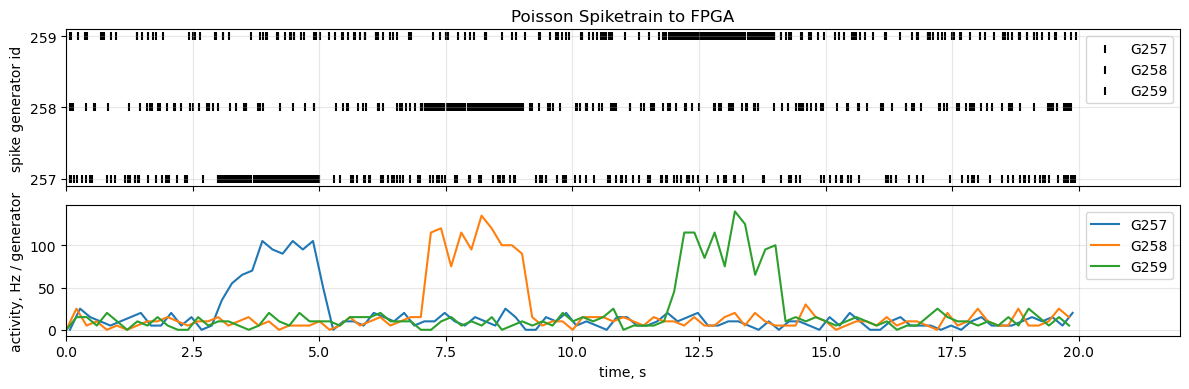

In [1662]:
input_spike_t  = np.asarray(spike_times)
input_spike_id = np.asarray(indices)

color_in = 'black'

# ------------------------------------------------------------
# COMPUTE INPUT GENERATOR ACTIVITY
# ------------------------------------------------------------
G_activity_rate = []
G_activity_x    = []
G_ids           = np.unique(input_spike_id)

for gid in G_ids:
    mask = input_spike_id == gid
    rate, x = population_activity(input_spike_t[mask], n_neurons=10)

    G_activity_rate.append(rate)
    G_activity_x.append(x)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 1]}
)

# ------------------------------------------------------------
# RASTER
# ------------------------------------------------------------
for gid in G_ids:
    mask = input_spike_id == gid

    ax1.scatter(
        input_spike_t[mask],
        input_spike_id[mask],
        marker='|',
        s=30,
        color=color_in,
        label=f'G{gid}'
    )

ax1.set_ylabel('spike generator id')
ax1.set_title('Poisson Spiketrain to FPGA')

ax1.set_yticks(G_ids)
ax1.set_yticklabels([str(int(gid)) for gid in G_ids])

ax1.grid(True, alpha=0.3)
ax1.legend()

# ------------------------------------------------------------
# INSTANTANEOUS ACTIVITY
# ------------------------------------------------------------
for k, gid in enumerate(G_ids):
    ax2.plot(
        G_activity_x[k],
        G_activity_rate[k],
        linestyle='-',
        label=f'G{gid}'
    )

ax2.set_xlabel('time, s')
ax2.set_ylabel('activity, Hz / generator')
ax2.set_xlim(0, t_tot)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

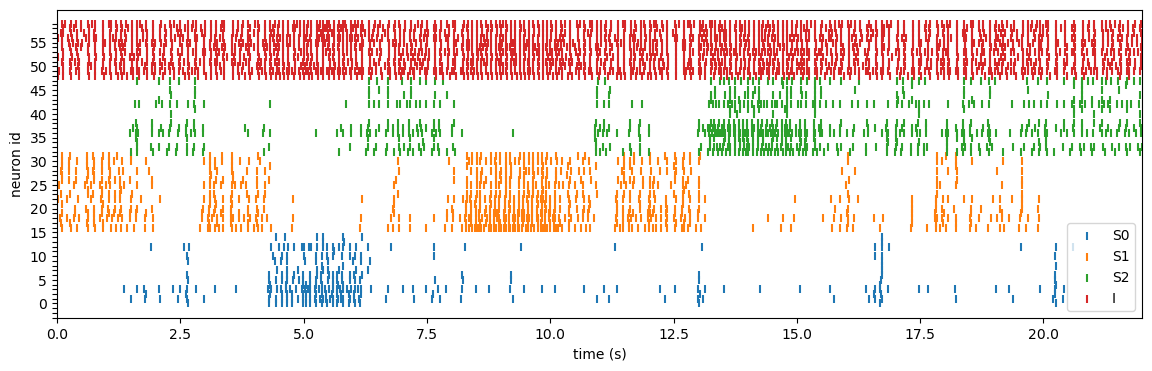

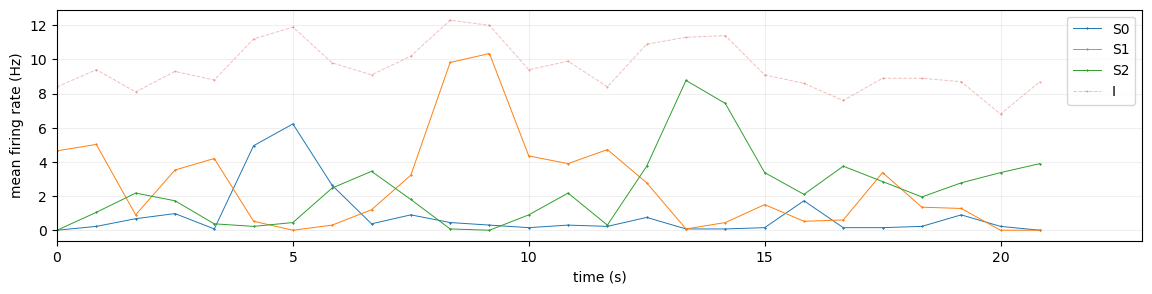

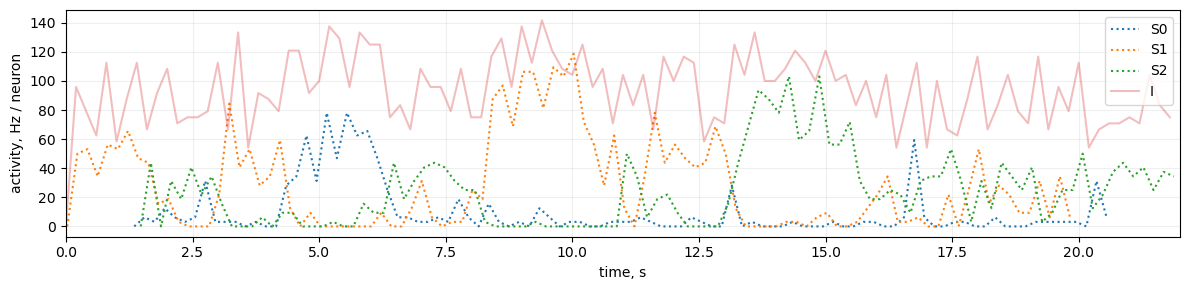

In [1663]:
color_I  = 'tab:red'
color_S  = ['tab:blue', 'tab:orange', 'tab:green', color_I]  # one per S population

# ------------------------------------------------------------
# TIME SHIFT
# ------------------------------------------------------------
t_0 = 0   # seconds, set this to the time you want to subtract


# ------------------------------------------------------------
# PLOT SPIKE RASTER
# ------------------------------------------------------------

fig1, ax1 = plt.subplots(figsize=(14, 4))

for s in range(int(NS)):
    ax1.scatter(
        S_spike_t[s] - t_0,
        S_spike_id[s],
        marker = '|',
        color  = color_S[s],
        label  = f'S{s}'
    )

if I_spike_t.size > 0:
    ax1.scatter(
        I_spike_t - t_0,
        I_spike_id,
        marker = '|',
        color  = color_I,
        label  = 'I'
    )

ticks = np.arange(0, NS * NE + NI, 1)
ax1.set_yticks(ticks)

k = 5
labels = [str(t) if t % k == 0 else '' for t in ticks]
ax1.set_yticklabels(labels)

ax1.set_xlabel('time (s)')
ax1.set_ylabel('display neuron id')
ax1.set_xlim(0, t_tot)
ax1.legend()

"""
ax1.scatter(
    input_spike_t - t_0,
    -1 * np.ones_like(input_spike_t),
    marker='|',
    color=color_in,
    label='Input'
)
"""

ticks = np.arange(-NG, NS*NE + NI, 1)
ax1.set_yticks(ticks)

# show labels only every k neurons
k = 5
labels = [str(t) if t % k == 0 else '' for t in ticks]
ax1.set_yticklabels(labels)

ax1.set_xlabel('time (s)')
ax1.set_ylabel('neuron id')

ax1.set_xlim(0, t_tot)

ax1.legend()
# ------------------------------------------------------------
# PLOT FIRING ACTIVITY AGAINST TIME
# ------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(14, 3))

for s in range(int(NS)):
    ax2.plot(
        t_axis,
        binPOP_rate[s],
        marker      = '*',
        linestyle   = '-',
        linewidth = 0.7,
        color       = color_S[s],
        markersize  = 1,
        label       = f'S{s}'
    )

if I_spike_t.size > 0:
     ax2.plot(
            t_axis,
            binPOP_rate[NS],
            marker     = '*',
            linestyle  = '--',
            color      = color_I,
            markersize = 1,
            alpha = 0.3,
            linewidth = 0.7,
            label      = f'I'
        )

ax2.set_xlabel('time (s)')
ax2.set_ylabel('mean firing rate (Hz)')
ax2.grid(True, alpha=0.2)
ax2.set_xlim(0, t_tot+1)
ax2.legend()

# ------------------------------------------------------------
# PLOT FIRING ACTIVITY AGAINST INPUT STIMULUS
# ------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(12, 3))

for s in range(int(NS)):
    ax3.plot(
        S_activity_x[s],
        S_activity_rate[s],
        linestyle  = ':',
        alpha = 1,
        color       = color_S[s],
        label=f"S{s}"
    )

if I_spike_t.size > 0:
    ax3.plot(
        I_activity_x,
        I_activity_rate,
        linestyle  = '-',
        alpha = 0.3,
        color = color_I,
        label="I"
    )

ax3.set_xlabel("time, s")
ax3.set_ylabel("activity, Hz / neuron")
ax3.set_xlim(0, t_tot)
ax3.legend()
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

